
=== customer_age ===
customer_age
10    0.003526
20    0.004901
30    0.008313
40    0.012048
50    0.019985
60    0.033046
70    0.040356
80    0.049345
90    0.052632
Name: fraud_bool, dtype: float64


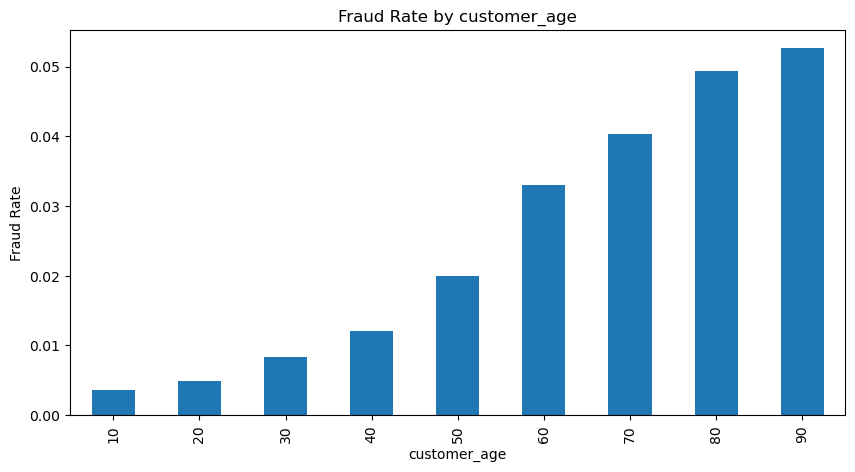


=== employment_status ===
employment_status
CF    0.001930
CE    0.002336
CD    0.003770
CB    0.006891
CA    0.012186
CG    0.015453
CC    0.024684
Name: fraud_bool, dtype: float64


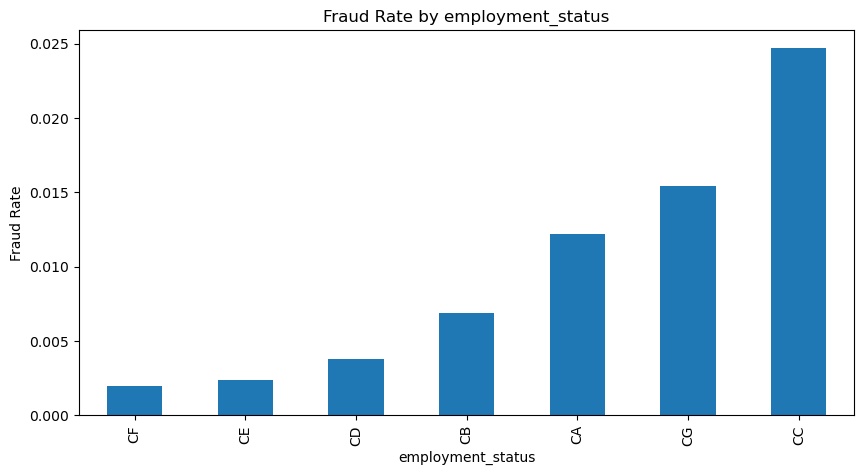


=== income ===
income
0.1    0.005773
0.2    0.006316
0.3    0.006649
0.4    0.007337
0.5    0.007949
0.6    0.008779
0.7    0.008819
0.8    0.010924
0.9    0.021638
Name: fraud_bool, dtype: float64


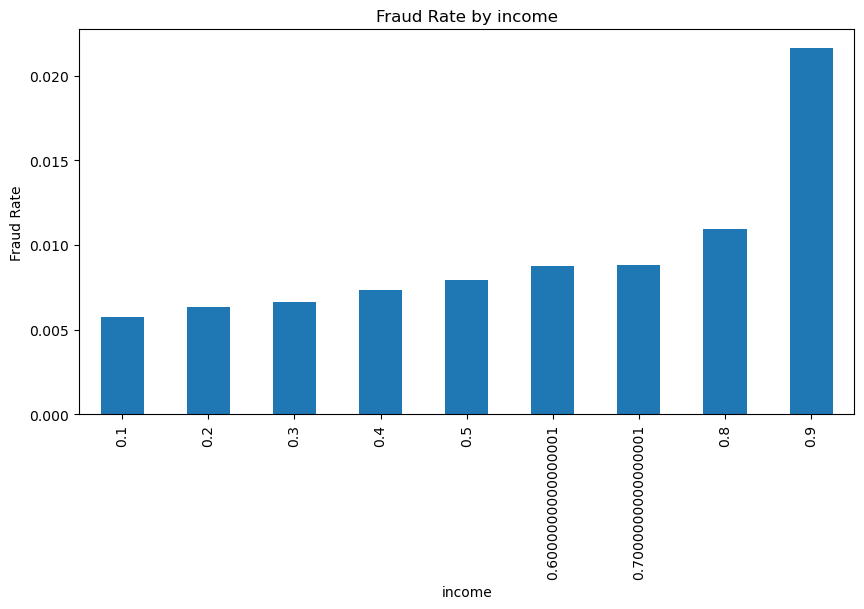

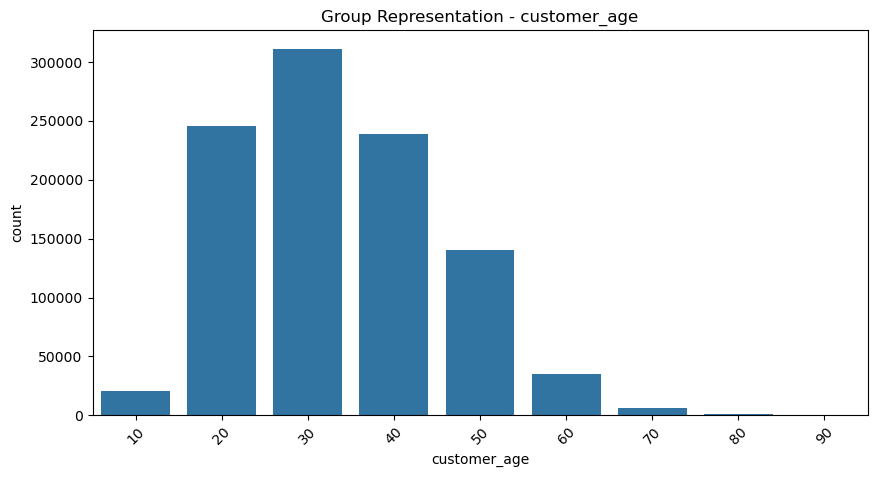

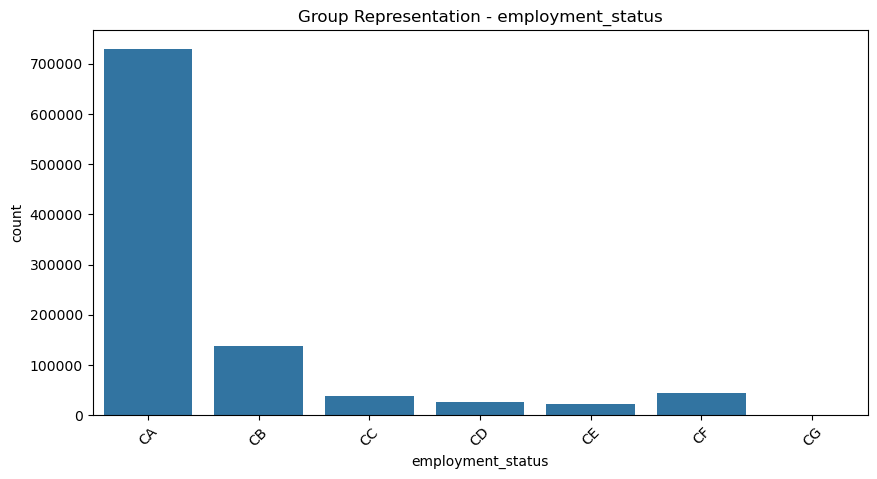

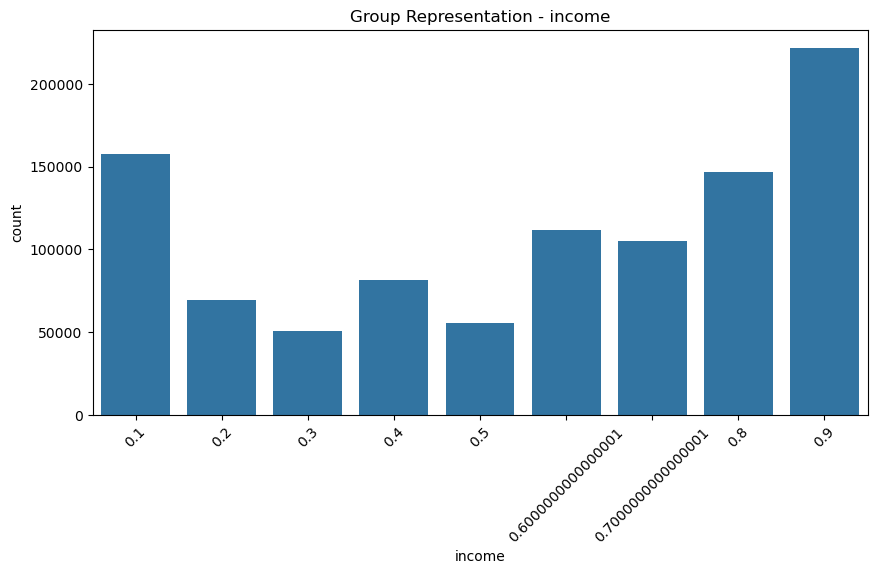


--- DISPARATE IMPACT ---
customer_age: 0.0670
employment_status: 0.0782
income: 0.2668

FAIRNESS ANALYSIS COMPLETED


In [1]:
# ==========================================================
# FAIRNESS_ANALYSIS.PY
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# LOAD DATA
# ==========================================================
df = pd.read_csv("Base.csv")

# ==========================================================
# SENSITIVE FEATURES
# ==========================================================
sensitive_cols = [
    "customer_age",
    "employment_status",
    "income"
]

# ==========================================================
# FRAUD RATE BY GROUP
# ==========================================================
for col in sensitive_cols:

    if col not in df.columns:
        continue

    print(f"\n=== {col} ===")

    fraud_by_group = (
        df.groupby(col)["fraud_bool"]
        .mean()
        .sort_values()
    )

    print(fraud_by_group)

    fraud_by_group.plot(
        kind="bar",
        figsize=(10,5)
    )

    plt.title(f"Fraud Rate by {col}")

    plt.ylabel("Fraud Rate")

    plt.show()

# ==========================================================
# GROUP REPRESENTATION
# ==========================================================
for col in sensitive_cols:

    if col not in df.columns:
        continue

    plt.figure(figsize=(10,5))

    sns.countplot(
        x=col,
        data=df
    )

    plt.title(f"Group Representation - {col}")

    plt.xticks(rotation=45)

    plt.show()

# ==========================================================
# DISPARATE IMPACT
# ==========================================================
print("\n--- DISPARATE IMPACT ---")

for col in sensitive_cols:

    if col not in df.columns:
        continue

    rates = (
        df.groupby(col)["fraud_bool"]
        .mean()
    )

    ratio = rates.min() / rates.max()

    print(f"{col}: {ratio:.4f}")

print("\nFAIRNESS ANALYSIS COMPLETED")